# Assignment 2: Sanskrit-to-English Neural Machine Translation
## AIL7390 — Deep Learning for NLP

**Models:** `Helsinki-NLP/opus-mt-inc-en` (MarianMT, ~140M params) and `google/byt5-small` (ByT5, ~300M params).

**Scoring:** `Score = 0.4 × BLEU + 0.3 × BERTScore + 0.15 × EfficiencyTime + 0.15 × EfficiencyParams`

### Pre-trained Models Used
- `Helsinki-NLP/opus-mt-inc-en` — MarianMT, Indic languages (incl. Sanskrit) → English (~140M params)
- `google/byt5-small` — Byte-level T5, language-agnostic (~300M params)

## 0. Setup & Installation

In [ ]:
# 0.1  Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = "/content/drive/MyDrive/AIL7390_Assignment2"
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/models", exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/outputs", exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")

Mounted at /content/drive
Project root: /content/drive/MyDrive/AIL7390_Assignment2


In [ ]:
# 0.2  Install Dependencies
!pip install -q transformers datasets accelerate sentencepiece protobuf
!pip install -q nltk bert-score

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.4 MB/s eta 0:00:00


True

In [ ]:
# 0.3  Data Setup
DATA_DIR = f"{PROJECT_ROOT}/data"
os.makedirs(DATA_DIR, exist_ok=True)

csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
print(f"CSV files found: {sorted(csv_files)}")
assert len(csv_files) >= 4, f"Need at least train/dev SA+EN CSVs. Found: {csv_files}"

CSV files found: ['dev_en_1000.csv', 'dev_sa_1000.csv', 'test_en_1000.csv', 'test_sa_1000.csv', 'train_en_10000.csv', 'train_sa_10000.csv']


In [ ]:
# 0.4  Imports
import os, re, time, warnings, random, gc, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from transformers import (
    AutoModelForSeq2SeqLM, AutoTokenizer,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback,
)

import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from bert_score import score as bert_score_fn

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 6)})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : Tesla T4


In [ ]:
# 0.5  Configuration
CFG = {
    "data_dir": DATA_DIR,
    "output_dir": f"{PROJECT_ROOT}/outputs",
    "model_dir": f"{PROJECT_ROOT}/models",

    # MarianMT: Indic languages → English (includes san_Deva)
    "model_name": "Helsinki-NLP/opus-mt-inc-en",
    # No language tokens needed. MarianMT infers from script.

    "batch_size": 16,          # MarianMT is smaller, can use larger batches
    "eval_batch_size": 32,
    "lr": 1e-4,                # Standard fine-tuning LR for MarianMT
    "epochs": 20,
    "warmup_steps": 200,
    "weight_decay": 0.01,
    "max_src_len": 128,
    "max_tgt_len": 128,
    "label_smoothing": 0.1,
    "gradient_accumulation_steps": 2,

    "beam_sizes": [1, 4, 8],
    "default_beam_size": 4,
    "length_penalty": 1.0,
    "no_repeat_ngram_size": 3,
    "max_gen_len": 128,

    "seed": 42,
}

def set_seed(seed=CFG["seed"]):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed()

def free_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def gpu_usage():
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"GPU: {used:.2f} / {total:.1f} GB ({used/total*100:.0f}%)")

gpu_usage()

GPU: 0.00 / 15.6 GB (0%)


## 1. Data Loading & Preprocessing

In [ ]:
# 1.1  Load & Clean
def load_split(split, data_dir=CFG["data_dir"]):
    en_files = sorted([f for f in os.listdir(data_dir) if f.startswith(f"{split}_en") and f.endswith(".csv")])
    sa_files = sorted([f for f in os.listdir(data_dir) if f.startswith(f"{split}_sa") and f.endswith(".csv")])
    if not en_files or not sa_files:
        raise FileNotFoundError(f"Missing {split} CSVs in {data_dir}\nAvailable: {sorted(os.listdir(data_dir))}")
    print(f"  Loading: {en_files[0]}, {sa_files[0]}")
    df_en = pd.read_csv(os.path.join(data_dir, en_files[0]), encoding="utf-8-sig")
    df_sa = pd.read_csv(os.path.join(data_dir, sa_files[0]), encoding="utf-8-sig")
    df_en.columns = df_en.columns.str.strip().str.replace("\ufeff", "")
    df_sa.columns = df_sa.columns.str.strip().str.replace("\ufeff", "")
    df = pd.merge(df_en, df_sa, on="Source_id", how="inner")
    df["Source_id"] = df["Source_id"].astype(int)
    return df

def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.strip().strip('"').strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f]", "", text)
    return text.strip()

def clean_df(df):
    df = df.copy()
    df["Sentence_en"] = df["Sentence_en"].apply(clean_text)
    df["Sentence_sa"] = df["Sentence_sa"].apply(clean_text)
    df = df[(df["Sentence_en"].str.len() > 0) & (df["Sentence_sa"].str.len() > 0)]
    df = df.drop_duplicates(subset="Source_id", keep="first")
    return df.sort_values("Source_id").reset_index(drop=True)

train_df = clean_df(load_split("train"))
dev_df   = clean_df(load_split("dev"))

try:
    test_df = clean_df(load_split("test"))
    HAS_TEST_REFS = "Sentence_en" in test_df.columns and test_df["Sentence_en"].str.len().sum() > 0
except Exception as e:
    print(f"Warning: {e}")
    sa_files = sorted([f for f in os.listdir(CFG["data_dir"]) if f.startswith("test_sa") and f.endswith(".csv")])
    test_df = pd.read_csv(os.path.join(CFG["data_dir"], sa_files[0]), encoding="utf-8-sig")
    test_df.columns = test_df.columns.str.strip().str.replace("\ufeff", "")
    test_df["Source_id"] = test_df["Source_id"].astype(int)
    test_df["Sentence_sa"] = test_df["Sentence_sa"].apply(clean_text)
    test_df = test_df.sort_values("Source_id").reset_index(drop=True)
    HAS_TEST_REFS = False

print(f"\nTrain: {len(train_df):,} | Dev: {len(dev_df):,} | Test: {len(test_df):,}")
print(f"Test has English references: {HAS_TEST_REFS}")
print(f"\nSample:")
print(f"  SA: {train_df.iloc[0]['Sentence_sa']}")
print(f"  EN: {train_df.iloc[0]['Sentence_en']}")

  Loading: train_en_10000.csv, train_sa_10000.csv
  Loading: dev_en_1000.csv, dev_sa_1000.csv
  Loading: test_en_1000.csv, test_sa_1000.csv

Train: 10,000 | Dev: 1,000 | Test: 1,000
Test has English references: True

Sample:
  SA: Ctrl, S नुत्वा रक्षन्तु।
  EN: Save it with Ctrl, S.


## 2. Evaluation Utilities

In [ ]:
# 2.1  BLEU
def compute_bleu(predictions, references):
    refs_tok  = [[nltk.word_tokenize(ref.lower())]  for ref in references]
    preds_tok = [nltk.word_tokenize(pred.lower()) for pred in predictions]
    return corpus_bleu(refs_tok, preds_tok)

def compute_sentence_bleu_list(predictions, references):
    smoothie = SmoothingFunction().method1
    return [sentence_bleu([nltk.word_tokenize(r.lower())], nltk.word_tokenize(p.lower()),
            smoothing_function=smoothie) for p, r in zip(predictions, references)]

In [ ]:
# 2.2  BERTScore
def compute_bertscore(predictions, references):
    P, R, F1 = bert_score_fn(predictions, references, lang="en",
                              rescale_with_baseline=True, verbose=False)
    return {"precision": P.mean().item(), "recall": R.mean().item(),
            "f1": F1.mean().item(), "f1_per_sentence": F1.tolist()}

In [ ]:
# 2.3  Translation + Evaluation helpers
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total params     : {total:,}")
    print(f"  Trainable params : {trainable:,}")
    return total, trainable

def translate_batch(model, tokenizer, texts, beam_size=4, max_len=128, batch_size=16):
    """
    Translate Sanskrit texts to English.
    MarianMT: no language tokens, no forced_bos_token_id, no src_lang.
    Just tokenize and generate.
    """
    model.eval()
    translations = []

    torch.cuda.synchronize() if torch.cuda.is_available() else None
    start = time.time()

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True,
                           truncation=True, max_length=max_len).to(DEVICE)
        with torch.no_grad():
            generated = model.generate(
                **inputs,
                num_beams=beam_size,
                max_length=max_len,
                length_penalty=CFG["length_penalty"],
                no_repeat_ngram_size=CFG["no_repeat_ngram_size"],
            )
        translations.extend(tokenizer.batch_decode(generated, skip_special_tokens=True))

    torch.cuda.synchronize() if torch.cuda.is_available() else None
    return translations, time.time() - start

def full_evaluation(predictions, references, label=""):
    bleu = compute_bleu(predictions, references)
    bert = compute_bertscore(predictions, references)
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  BLEU (NLTK default) : {bleu:.4f}")
    print(f"  BERTScore F1        : {bert['f1']:.4f}")
    print(f"  BERTScore Precision : {bert['precision']:.4f}")
    print(f"  BERTScore Recall    : {bert['recall']:.4f}")
    return {"label": label, "bleu": bleu, "bertscore_f1": bert["f1"],
            "bertscore_p": bert["precision"], "bertscore_r": bert["recall"],
            "f1_per_sentence": bert["f1_per_sentence"]}

print("Evaluation utilities ready")

Evaluation utilities ready


In [ ]:
# Check sentence lengths to decide max_length
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-inc-en")

sa_lens = [len(tok(s)["input_ids"]) for s in train_df["Sentence_sa"]]
en_lens = [len(tok(s)["input_ids"]) for s in train_df["Sentence_en"]]

import numpy as np
print("Sanskrit token lengths:")
print(f"  Mean: {np.mean(sa_lens):.0f} | Median: {np.median(sa_lens):.0f} | 95th: {np.percentile(sa_lens, 95):.0f} | 99th: {np.percentile(sa_lens, 99):.0f} | Max: {max(sa_lens)}")
print(f"\nEnglish token lengths:")
print(f"  Mean: {np.mean(en_lens):.0f} | Median: {np.median(en_lens):.0f} | 95th: {np.percentile(en_lens, 95):.0f} | 99th: {np.percentile(en_lens, 99):.0f} | Max: {max(en_lens)}")
print(f"\nSentences truncated at 128: SA={sum(1 for l in sa_lens if l > 128)} ({sum(1 for l in sa_lens if l > 128)/len(sa_lens)*100:.1f}%) | EN={sum(1 for l in en_lens if l > 128)} ({sum(1 for l in en_lens if l > 128)/len(en_lens)*100:.1f}%)")
print(f"Sentences truncated at 256: SA={sum(1 for l in sa_lens if l > 256)} ({sum(1 for l in sa_lens if l > 256)/len(sa_lens)*100:.1f}%) | EN={sum(1 for l in en_lens if l > 256)} ({sum(1 for l in en_lens if l > 256)/len(en_lens)*100:.1f}%)")

Sanskrit token lengths:
  Mean: 31 | Median: 27 | 95th: 65 | 99th: 89 | Max: 204

English token lengths:
  Mean: 36 | Median: 32 | 95th: 78 | 99th: 106 | Max: 331

Sentences truncated at 128: SA=6 (0.1%) | EN=29 (0.3%)
Sentences truncated at 256: SA=0 (0.0%) | EN=1 (0.0%)


## 3. Load Model & Tokenizer

`Helsinki-NLP/opus-mt-inc-en` is a MarianMT model trained on Indic→English translation.
It explicitly supports `san_Deva` (Sanskrit in Devanagari script).

**Architecture:** Transformer encoder-decoder (6+6 layers), 8 attention heads, d_model=512.
MarianMT = BART-style architecture. No language tokens needed — just tokenize and generate.

In [ ]:
# 3.1  Load MarianMT
print("Loading Helsinki-NLP/opus-mt-inc-en ...")
tokenizer = AutoTokenizer.from_pretrained(CFG["model_name"])
model = AutoModelForSeq2SeqLM.from_pretrained(CFG["model_name"]).to(DEVICE)
model.eval()

print(f"Model loaded on {DEVICE}")
total_params, _ = count_parameters(model)
gpu_usage()

# Quick sanity check — translate one sentence
test_sent = train_df.iloc[0]["Sentence_sa"]
inputs = tokenizer(test_sent, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    out = model.generate(**inputs, num_beams=4, max_length=128)
print(f"\nSanity check:")
print(f"  SA : {test_sent}")
print(f"  REF: {train_df.iloc[0]['Sentence_en']}")
print(f"  GEN: {tokenizer.decode(out[0], skip_special_tokens=True)}")

Loading Helsinki-NLP/opus-mt-inc-en ...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/969k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/306M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Model loaded on cuda
  Total params     : 139,601,408
  Trainable params : 139,601,408
GPU: 0.56 / 15.6 GB (4%)

Sanity check:
  SA : Ctrl, S नुत्वा रक्षन्तु।
  REF: Save it with Ctrl, S.
  GEN: Ctrl, Swipe finger object.


## 4. Fine-Tune on Assignment Data

**Key advantages of MarianMT:**
- Clean BART-style architecture — no tied weights bugs, no fp16 nan, no decoder_input_ids conflicts
- Standard `Seq2SeqTrainer` works out of the box
- ~140M params — good efficiency score

In [ ]:
# 4.1  Tokenize with HuggingFace Datasets
from datasets import Dataset as HFDataset

def make_hf_dataset(df, tokenizer, max_src_len=128, max_tgt_len=128):
    ds = HFDataset.from_pandas(df[["Sentence_sa", "Sentence_en"]])

    def preprocess(examples):
        model_inputs = tokenizer(
            examples["Sentence_sa"], max_length=max_src_len, truncation=True)
        labels = tokenizer(
            text_target=examples["Sentence_en"], max_length=max_tgt_len, truncation=True)
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    return ds.map(preprocess, batched=True, remove_columns=["Sentence_sa", "Sentence_en"])

tokenizer = AutoTokenizer.from_pretrained(CFG["model_name"])
train_dataset = make_hf_dataset(train_df, tokenizer, CFG["max_src_len"], CFG["max_tgt_len"])
dev_dataset   = make_hf_dataset(dev_df, tokenizer, CFG["max_src_len"], CFG["max_tgt_len"])
print(f"Train: {len(train_dataset)} | Dev: {len(dev_dataset)}")
print(f"Features: {train_dataset.features}")

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train: 10000 | Dev: 1000
Features: {'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8')), 'labels': List(Value('int64'))}


In [ ]:
# 4.2  Fine-Tuning with Seq2SeqTrainer
CKPT_DIR  = os.path.join(CFG["model_dir"], "marian_sa_ft")
BEST_CKPT = os.path.join(CFG["model_dir"], "marian_sa_ft_best")

if os.path.exists(os.path.join(BEST_CKPT, "model.safetensors")) or os.path.exists(os.path.join(BEST_CKPT, "pytorch_model.bin")):
    print("Starting fine-tuning ...")
    free_memory()
    model = AutoModelForSeq2SeqLM.from_pretrained(CFG["model_name"]).to(DEVICE)
    gpu_usage()

    training_args = Seq2SeqTrainingArguments(
        output_dir=CKPT_DIR,
        num_train_epochs=CFG["epochs"],
        per_device_train_batch_size=CFG["batch_size"],
        per_device_eval_batch_size=CFG["eval_batch_size"],
        learning_rate=CFG["lr"],
        warmup_steps=CFG["warmup_steps"],
        weight_decay=CFG["weight_decay"],
        label_smoothing_factor=CFG["label_smoothing"],
        fp16=torch.cuda.is_available(),  # MarianMT works fine with fp16!
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        predict_with_generate=False,
        logging_steps=50,
        report_to="none",
        seed=CFG["seed"],
        gradient_accumulation_steps=CFG["gradient_accumulation_steps"],
    )

    data_collator = DataCollatorForSeq2Seq(
        tokenizer, model=model, padding=True, label_pad_token_id=tokenizer.pad_token_id
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=dev_dataset,
        data_collator=data_collator,
        processing_class=tokenizer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )

    train_result = trainer.train()

    trainer.save_model(BEST_CKPT)
    tokenizer.save_pretrained(BEST_CKPT)
    print(f"Best model saved to {BEST_CKPT}")

    ft_history = trainer.state.log_history
    with open(os.path.join(CFG["output_dir"], "training_history.json"), "w") as f:
        json.dump(ft_history, f)

    model = trainer.model

model.eval()
gpu_usage()

Starting fine-tuning ...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


GPU: 7.06 / 15.6 GB (45%)


Epoch,Training Loss,Validation Loss
1,5.323966,2.446203
2,4.709530,2.353196
3,4.294637,2.333858
4,3.985395,2.337526
5,3.693059,2.362075
6,3.518623,2.387953


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_positions.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to /content/drive/MyDrive/AIL7390_Assignment2/models/marian_sa_ft_best
GPU: 6.50 / 15.6 GB (42%)


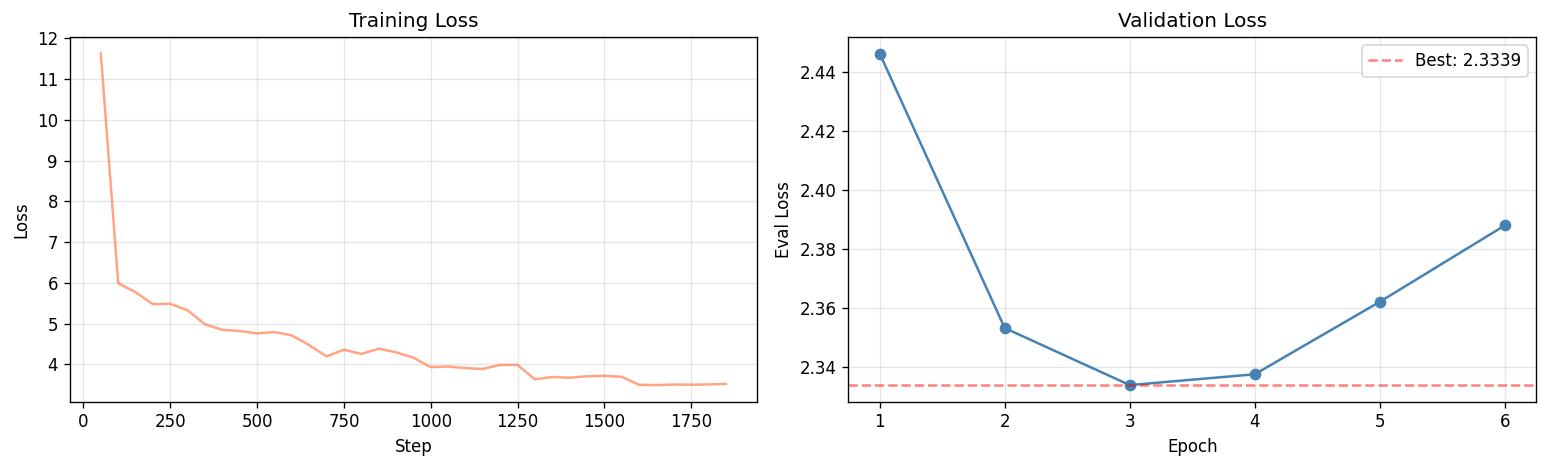

In [ ]:
# 4.3  Training Curves
if ft_history is None:
    hist_path = os.path.join(CFG["output_dir"], "training_history.json")
    ft_history = json.load(open(hist_path)) if os.path.exists(hist_path) else []

if ft_history:
    train_losses = [(h["step"], h["loss"]) for h in ft_history if "loss" in h and "eval_loss" not in h]
    eval_losses  = [(h["epoch"], h["eval_loss"]) for h in ft_history if "eval_loss" in h]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    if train_losses:
        ax1.plot(*zip(*train_losses), color="coral", alpha=0.7)
        ax1.set_xlabel("Step"); ax1.set_ylabel("Loss"); ax1.set_title("Training Loss"); ax1.grid(True, alpha=0.3)
    if eval_losses:
        ax2.plot(*zip(*eval_losses), "o-", color="steelblue")
        ax2.set_xlabel("Epoch"); ax2.set_ylabel("Eval Loss"); ax2.set_title("Validation Loss"); ax2.grid(True, alpha=0.3)
        best_ep = min(eval_losses, key=lambda x: x[1])
        ax2.axhline(best_ep[1], color="red", ls="--", alpha=0.5, label=f"Best: {best_ep[1]:.4f}")
        ax2.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(CFG["output_dir"], "training_curves.png"), dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
# 4.4  Dev Eval (fine-tuned)
print("Translating dev set with fine-tuned model ...")
ft_preds, ft_time = translate_batch(model, tokenizer, dev_df["Sentence_sa"].tolist(),
    beam_size=CFG["default_beam_size"], max_len=CFG["max_gen_len"], batch_size=CFG["eval_batch_size"])

ft_dev_results = full_evaluation(ft_preds, dev_df["Sentence_en"].tolist(), "Fine-Tuned MarianMT (Dev)")
print(f"  Inference time: {ft_time:.2f}s")

# Show samples
print("\nSample translations:")
for i in range(5):
    print(f"  SA : {dev_df.iloc[i]['Sentence_sa'][:80]}")
    print(f"  REF: {dev_df.iloc[i]['Sentence_en'][:80]}")
    print(f"  GEN: {ft_preds[i][:80]}")
    print()

Translating dev set with fine-tuned model ...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Fine-Tuned MarianMT (Dev)
  BLEU (NLTK default) : 0.1922
  BERTScore F1        : 0.4964
  BERTScore Precision : 0.5160
  BERTScore Recall    : 0.4770
  Inference time: 56.82s

Sample translations:
  SA : ते वीराः ।
  REF: Those are brave men.
  GEN: Those two are warriors.

  SA : 'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां कारयति ।
  REF: Infinite loop can cause the system to become unresponsive.
  GEN: Inflate loop is done by the application.

  SA : ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः।
  REF: And they spit upon him, and took the reed, and smote him on the head.
  GEN: And they laid hold on him, and put him in a tomb whereon was laid.

  SA : एते तिथी ।
  REF: These two are dates.
  GEN: These are two.

  SA : बहुविचारेषु जातषु पितर उत्थाय कथितवान्, हे भ्रातरो यथा भिन्नदेशीयलोका मम मुखात् 
  REF: And when there had been much disputing, Peter rose up, and said unto them, Men a
  GEN: And he said unto them, Men and brethren, I have called for you, that ye should 

## 5. Beam Search Ablation


Beam = 1 ...
  BLEU=0.1779  time=28.50s

Beam = 4 ...
  BLEU=0.1922  time=56.83s

Beam = 8 ...
  BLEU=0.1962  time=98.43s

 beam     bleu      time
    1 0.177937 28.495958
    4 0.192208 56.831718
    8 0.196213 98.425991


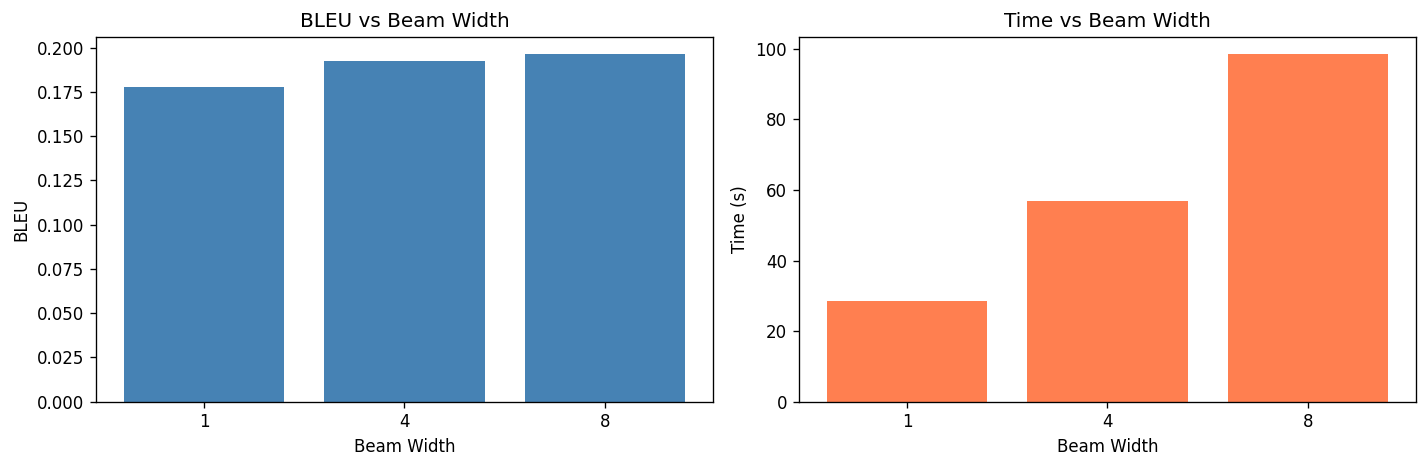


Best beam: 8


In [ ]:
# 5.1  Beam Sweep
beam_results = []
for beam in CFG["beam_sizes"]:
    print(f"\nBeam = {beam} ...")
    preds, t = translate_batch(model, tokenizer, dev_df["Sentence_sa"].tolist(),
                               beam_size=beam, max_len=CFG["max_gen_len"], batch_size=CFG["eval_batch_size"])
    bleu = compute_bleu(preds, dev_df["Sentence_en"].tolist())
    beam_results.append({"beam": beam, "bleu": bleu, "time": t})
    print(f"  BLEU={bleu:.4f}  time={t:.2f}s")

beam_df = pd.DataFrame(beam_results)
print("\n" + beam_df.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar([str(b) for b in beam_df["beam"]], beam_df["bleu"], color="steelblue")
ax1.set_xlabel("Beam Width"); ax1.set_ylabel("BLEU"); ax1.set_title("BLEU vs Beam Width")
ax2.bar([str(b) for b in beam_df["beam"]], beam_df["time"], color="coral")
ax2.set_xlabel("Beam Width"); ax2.set_ylabel("Time (s)"); ax2.set_title("Time vs Beam Width")
plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "beam_ablation.png"), dpi=150, bbox_inches="tight")
plt.show()

BEST_BEAM = int(beam_df.loc[beam_df["bleu"].idxmax(), "beam"])
print(f"\nBest beam: {BEST_BEAM}")

## 6. Full Evaluation — Dev & Test

In [ ]:
# 6.1  Dev (full metrics)
print(f"Dev eval with beam={BEST_BEAM} ...")
dev_preds, dev_time = translate_batch(model, tokenizer, dev_df["Sentence_sa"].tolist(),
    beam_size=BEST_BEAM, max_len=CFG["max_gen_len"], batch_size=CFG["eval_batch_size"])
dev_results = full_evaluation(dev_preds, dev_df["Sentence_en"].tolist(), "Fine-Tuned MarianMT (Dev)")
dev_total_params, _ = count_parameters(model)
print(f"  Inference time : {dev_time:.2f}s ({len(dev_df)/dev_time:.1f} sent/s)")

Dev eval with beam=8 ...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Fine-Tuned MarianMT (Dev)
  BLEU (NLTK default) : 0.1962
  BERTScore F1        : 0.4961
  BERTScore Precision : 0.5150
  BERTScore Recall    : 0.4772
  Total params     : 139,601,408
  Trainable params : 139,601,408
  Inference time : 98.41s (10.2 sent/s)


In [ ]:
# 6.2  Test
print(f"Test eval with beam={BEST_BEAM} ...")
test_preds, test_time = translate_batch(model, tokenizer, test_df["Sentence_sa"].tolist(),
    beam_size=BEST_BEAM, max_len=CFG["max_gen_len"], batch_size=CFG["eval_batch_size"])

if HAS_TEST_REFS:
    test_results = full_evaluation(test_preds, test_df["Sentence_en"].tolist(), "Fine-Tuned MarianMT (Test)")
else:
    print("  No test references — skipping metrics")
    test_results = {"bleu": None, "bertscore_f1": None, "f1_per_sentence": []}
print(f"  Inference time : {test_time:.2f}s ({len(test_df)/test_time:.1f} sent/s)")

test_df_out = test_df[["Source_id"]].copy()
test_df_out["Sentence_en"] = test_preds
test_df_out.to_csv(os.path.join(CFG["output_dir"], "submission.csv"), index=False, encoding="utf-8")
print("submission.csv saved")

Test eval with beam=8 ...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Fine-Tuned MarianMT (Test)
  BLEU (NLTK default) : 0.2014
  BERTScore F1        : 0.4986
  BERTScore Precision : 0.5135
  BERTScore Recall    : 0.4833
  Inference time : 87.43s (11.4 sent/s)
submission.csv saved


In [ ]:
# 6.3  Summary
summary_data = [
    {"Split": "Dev (FT)", "BLEU": f"{dev_results['bleu']:.4f}", "BERTScore F1": f"{dev_results['bertscore_f1']:.4f}",
     "Time": f"{dev_time:.2f}s", "Params": f"{dev_total_params:,}", "Beam": BEST_BEAM},
]
if HAS_TEST_REFS and test_results.get("bleu"):
    summary_data.append({"Split": "Test (FT)", "BLEU": f"{test_results['bleu']:.4f}",
        "BERTScore F1": f"{test_results['bertscore_f1']:.4f}", "Time": f"{test_time:.2f}s",
        "Params": f"{dev_total_params:,}", "Beam": BEST_BEAM})
else:
    summary_data.append({"Split": "Test (FT)", "BLEU": "N/A", "BERTScore F1": "N/A",
        "Time": f"{test_time:.2f}s", "Params": f"{dev_total_params:,}", "Beam": BEST_BEAM})

print("\n" + "="*80)
print("  RESULTS SUMMARY")
print("="*80)
print(pd.DataFrame(summary_data).to_string(index=False))
pd.DataFrame(summary_data).to_csv(os.path.join(CFG["output_dir"], "results_summary.csv"), index=False)


  RESULTS SUMMARY
    Split   BLEU BERTScore F1   Time      Params  Beam
 Dev (FT) 0.1962       0.4961 98.41s 139,601,408     8
Test (FT) 0.2014       0.4986 87.43s 139,601,408     8


## 7. Translation Examples — Error Analysis (Required)

In [ ]:
# 7.1  Error analysis
if HAS_TEST_REFS:
    a_preds, a_refs, a_src, a_label = test_preds, test_df["Sentence_en"].tolist(), test_df["Sentence_sa"].tolist(), "Test"
    a_bert = test_results["f1_per_sentence"]
else:
    a_preds, a_refs, a_src, a_label = dev_preds, dev_df["Sentence_en"].tolist(), dev_df["Sentence_sa"].tolist(), "Dev"
    a_bert = compute_bertscore(dev_preds, dev_df["Sentence_en"].tolist())["f1_per_sentence"]

sent_bleus = compute_sentence_bleu_list(a_preds, a_refs)
sorted_idx = np.argsort(sent_bleus)

for title, indices in [("TOP 5 — Best", sorted_idx[-5:][::-1]), ("BOTTOM 5 — Worst", sorted_idx[:5])]:
    print(f"\n{'='*80}\n  {title} ({a_label})\n{'='*80}")
    for rank, idx in enumerate(indices, 1):
        print(f"\n#{rank}  BLEU={sent_bleus[idx]:.4f}  BERT={a_bert[idx]:.4f}")
        print(f"  SRC: {a_src[idx][:120]}")
        print(f"  REF: {a_refs[idx][:120]}")
        print(f"  GEN: {a_preds[idx][:120]}")


  TOP 5 — Best (Test)

#1  BLEU=1.0000  BERT=1.0000
  SRC: अधुना वयं NetBeans IDE उपयुज्य, किञ्चन सरलं Java वेब् प्रोजेक्ट् निर्माणं कथम् इति पश्याम ।
  REF: Now, let us see how to create a simple Java web project using NetBeans IDE.
  GEN: Now, let us see how to create a simple Java web project using NetBeans IDE.

#2  BLEU=1.0000  BERT=1.0000
  SRC: स्पोकन ट्युटोरियल प्रोजेक्ट तु Talk to a Teacher इति परियोजनायाः भागः अस्ति।
  REF: Spoken Tutorial project is a part of the Talk to a Teacher project.
  GEN: Spoken Tutorial project is a part of the Talk to a Teacher project.

#3  BLEU=1.0000  BERT=1.0000
  SRC: एतत् मिशन् विषये अधिकविवरणानि अस्यां पर्चन्याम् उपलभ्यते ।
  REF: More information on this mission is available at this link.
  GEN: More information on this mission is available at this link.

#4  BLEU=1.0000  BERT=1.0000
  SRC: इदं स्टेट्मेण्ट्, वेरियेबल् num इत्यस्य अड्रेस् इतीदं प्रिण्ट् करोति ।
  REF: This statement will print the address of the variable num.
  GEN: This st

## 8. Efficiency Metrics (Required)

In [ ]:
# 8.1  Efficiency
print("="*60)
print("  EFFICIENCY METRICS")
print("="*60)
print(f"  Model             : {CFG['model_name']}")
print(f"  Beam width        : {BEST_BEAM}")
print(f"  Test set size     : {len(test_df)} sentences")
print(f"  Total parameters  : {dev_total_params:,}")
print(f"  Inference time    : {test_time:.2f} seconds")
print(f"  Throughput        : {len(test_df)/test_time:.1f} sentences/sec")
print(f"  Avg time/sentence : {test_time/len(test_df)*1000:.1f} ms")

  EFFICIENCY METRICS
  Model             : Helsinki-NLP/opus-mt-inc-en
  Beam width        : 8
  Test set size     : 1000 sentences
  Total parameters  : 139,601,408
  Inference time    : 87.43 seconds
  Throughput        : 11.4 sentences/sec
  Avg time/sentence : 87.4 ms


## 9. Report Plots

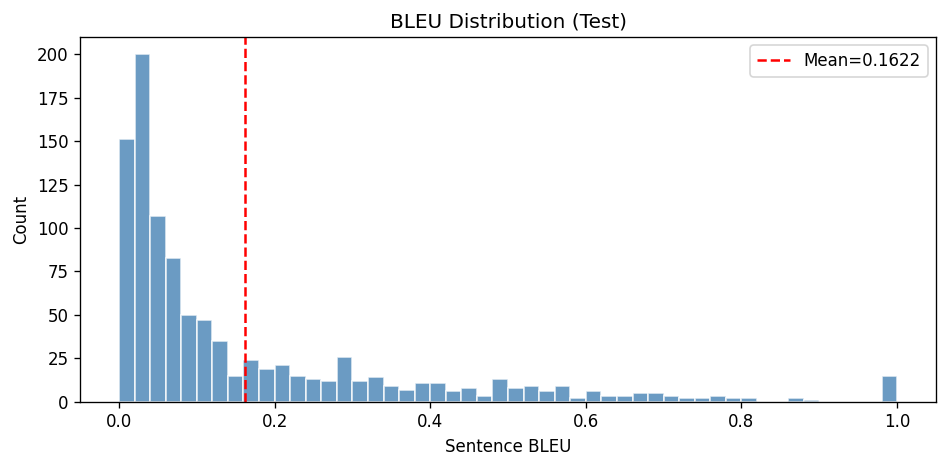

In [ ]:
# 9.1  BLEU Distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sent_bleus, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(np.mean(sent_bleus), color="red", ls="--", label=f"Mean={np.mean(sent_bleus):.4f}")
ax.set_xlabel("Sentence BLEU"); ax.set_ylabel("Count"); ax.set_title(f"BLEU Distribution ({a_label})")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "bleu_distribution.png"), dpi=150, bbox_inches="tight"); plt.show()

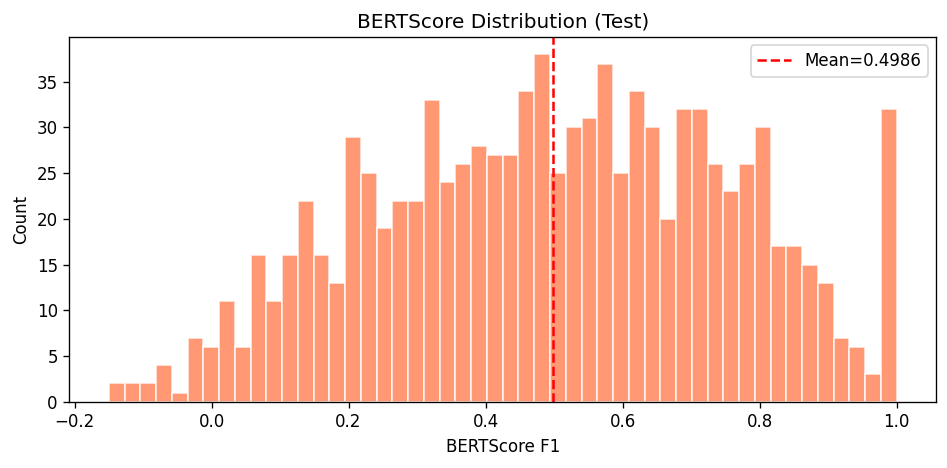

In [ ]:
# 9.2  BERTScore Distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(a_bert, bins=50, color="coral", edgecolor="white", alpha=0.8)
ax.axvline(np.mean(a_bert), color="red", ls="--", label=f"Mean={np.mean(a_bert):.4f}")
ax.set_xlabel("BERTScore F1"); ax.set_ylabel("Count"); ax.set_title(f"BERTScore Distribution ({a_label})")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "bertscore_distribution.png"), dpi=150, bbox_inches="tight"); plt.show()

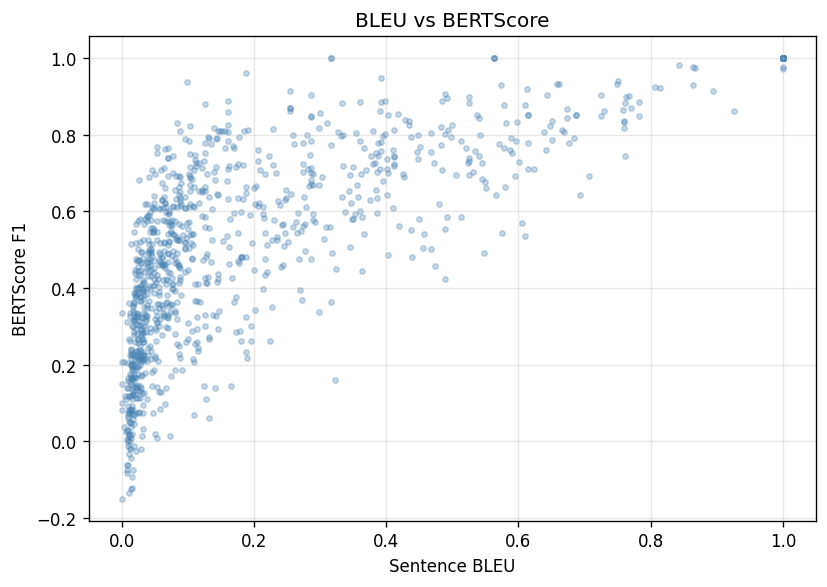

In [ ]:
# 9.3  BLEU vs BERTScore
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sent_bleus, a_bert, alpha=0.3, s=10, color="steelblue")
ax.set_xlabel("Sentence BLEU"); ax.set_ylabel("BERTScore F1"); ax.set_title("BLEU vs BERTScore"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "bleu_vs_bertscore.png"), dpi=150, bbox_inches="tight"); plt.show()

In [ ]:
# Free MarianMT from GPU before loading ByT5
try:
    del model
    del trainer
except:
    pass
free_memory()
print("GPU cleared for ByT5")
gpu_usage()

## 10. Experiment 2 — ByT5-small (Byte-level T5)

**Why ByT5?** It operates on raw UTF-8 bytes — no tokenizer, no vocabulary limitations.
For morphologically rich languages like Sanskrit, byte-level models avoid tokenization artifacts
that plague subword models (SentencePiece splitting Devanagari characters mid-syllable).

- `google/byt5-small` — 300M params, T5 architecture, works on ANY language
- Task prefix: `"translate Sanskrit to English: "` (standard T5 convention)
- Slower inference (byte-level decoding) but potentially better handling of Sanskrit morphology

In [ ]:
# 10.1  Load ByT5-small
from transformers import AutoTokenizer as ByT5Tokenizer, AutoModelForSeq2SeqLM as ByT5Model

print("Loading google/byt5-small ...")
byt5_tokenizer = ByT5Tokenizer.from_pretrained("google/byt5-small")
byt5_model = ByT5Model.from_pretrained("google/byt5-small").to(DEVICE)
byt5_model.eval()

byt5_params, _ = count_parameters(byt5_model)
gpu_usage()

# Sanity check
test_input = "translate Sanskrit to English: " + train_df.iloc[0]["Sentence_sa"]
inputs = byt5_tokenizer(test_input, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    out = byt5_model.generate(**inputs, max_length=128)
print(f"\nSanity check (before fine-tuning — will be garbage, ByT5 is not a translation model):")
print(f"  Input: {test_input[:80]}")
print(f"  Output: {byt5_tokenizer.decode(out[0], skip_special_tokens=True)[:80]}")

Loading google/byt5-small ...


config.json:   0%|          | 0.00/698 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

  Total params     : 300,768,256
  Trainable params : 300,768,256
GPU: 1.21 / 15.6 GB (8%)

Sanity check (before fine-tuning — will be garbage, ByT5 is not a translation model):
  Input: translate Sanskrit to English: Ctrl, S नुत्वा रक्षन्तु।
  Output:  Sanskrit to English translations - MyMemory
Sanskrit to English
Sanskrit to Eng


In [ ]:
# 10.2  Tokenize for ByT5
from datasets import Dataset as HFDataset

BYT5_PREFIX = "translate Sanskrit to English: "

def make_byt5_dataset(df, tokenizer, max_src_len=256, max_tgt_len=128):
    ds = HFDataset.from_pandas(df[["Sentence_sa", "Sentence_en"]])

    def preprocess(examples):
        inputs = [BYT5_PREFIX + t for t in examples["Sentence_sa"]]
        # ByT5 needs longer max_length since it tokenizes at byte level
        model_inputs = tokenizer(inputs, max_length=max_src_len, truncation=True)
        labels = tokenizer(text_target=examples["Sentence_en"], max_length=max_tgt_len, truncation=True)
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    return ds.map(preprocess, batched=True, remove_columns=["Sentence_sa", "Sentence_en"])

byt5_tokenizer = ByT5Tokenizer.from_pretrained("google/byt5-small")
byt5_train = make_byt5_dataset(train_df, byt5_tokenizer)
byt5_dev   = make_byt5_dataset(dev_df, byt5_tokenizer)
print(f"ByT5 — Train: {len(byt5_train)} | Dev: {len(byt5_dev)}")
print(f"Sample input_ids length: {len(byt5_train[0]['input_ids'])} (byte-level, much longer than subword)")

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

ByT5 — Train: 10000 | Dev: 1000
Sample input_ids length: 86 (byte-level, much longer than subword)


In [ ]:
# 10.3  Fine-Tune ByT5
BYT5_CKPT_DIR  = os.path.join(CFG["model_dir"], "byt5_sa_ft")
BYT5_BEST_CKPT = os.path.join(CFG["model_dir"], "byt5_sa_ft_best")

if os.path.exists(os.path.join(BYT5_BEST_CKPT, "model.safetensors")) or os.path.exists(os.path.join(BYT5_BEST_CKPT, "pytorch_model.bin")):
    print("ByT5 checkpoint found — loading")
    byt5_model = ByT5Model.from_pretrained(BYT5_BEST_CKPT).to(DEVICE)
    byt5_tokenizer = ByT5Tokenizer.from_pretrained(BYT5_BEST_CKPT)
    byt5_history = None
    print("ByT5 loaded")
else:
    print("Fine-tuning ByT5-small ...")
    free_memory()
    byt5_model = ByT5Model.from_pretrained("google/byt5-small").to(DEVICE)
    gpu_usage()

    byt5_args = Seq2SeqTrainingArguments(
        output_dir=BYT5_CKPT_DIR,
        num_train_epochs=5,           # fewer epochs — ByT5 is slower per step
        per_device_train_batch_size=8, # smaller batch — byte seqs are longer
        per_device_eval_batch_size=16,
        learning_rate=3e-4,           # ByT5/T5 needs higher LR
        warmup_steps=200,
        weight_decay=0.01,
        label_smoothing_factor=0.1,
        fp16=False,                   # ByT5 can have fp16 issues like mT5
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        predict_with_generate=False,
        logging_steps=50,
        report_to="none",
        seed=CFG["seed"],
        gradient_accumulation_steps=4,
    )

    byt5_collator = DataCollatorForSeq2Seq(
        byt5_tokenizer, model=byt5_model, padding=True,
        label_pad_token_id=byt5_tokenizer.pad_token_id
    )

    byt5_trainer = Seq2SeqTrainer(
        model=byt5_model,
        args=byt5_args,
        train_dataset=byt5_train,
        eval_dataset=byt5_dev,
        data_collator=byt5_collator,
        processing_class=byt5_tokenizer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    byt5_trainer.train()

    byt5_trainer.save_model(BYT5_BEST_CKPT)
    byt5_tokenizer.save_pretrained(BYT5_BEST_CKPT)
    print(f"ByT5 saved to {BYT5_BEST_CKPT}")

    byt5_history = byt5_trainer.state.log_history
    with open(os.path.join(CFG["output_dir"], "byt5_training_history.json"), "w") as f:
        json.dump(byt5_history, f)

    byt5_model = byt5_trainer.model

byt5_model.eval()
gpu_usage()

Fine-tuning ByT5-small ...


Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


GPU: 1.22 / 15.6 GB (8%)


Epoch,Training Loss,Validation Loss
1,13.226193,2.972662
2,8.363565,1.809852
3,6.333298,1.402749
4,5.752556,1.333962
5,5.627137,1.323833


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

ByT5 saved to /content/drive/MyDrive/AIL7390_Assignment2/models/byt5_sa_ft_best
GPU: 3.63 / 15.6 GB (23%)


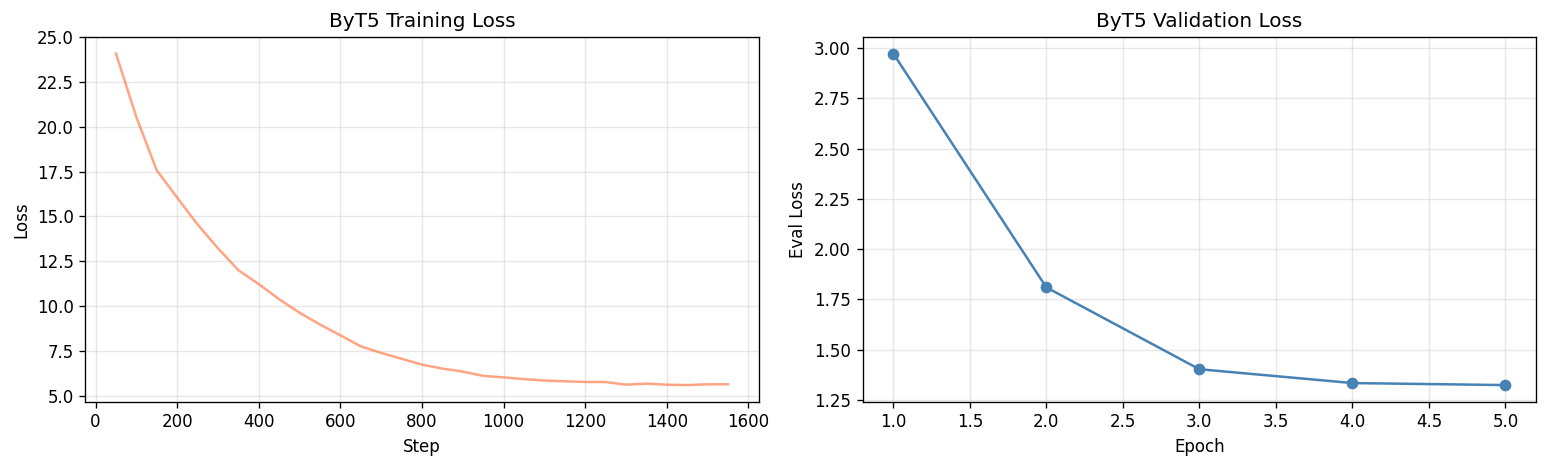

In [ ]:
# 10.4  ByT5 Training Curves
if byt5_history is None:
    hp = os.path.join(CFG["output_dir"], "byt5_training_history.json")
    byt5_history = json.load(open(hp)) if os.path.exists(hp) else []

if byt5_history:
    tl = [(h["step"], h["loss"]) for h in byt5_history if "loss" in h and "eval_loss" not in h]
    el = [(h["epoch"], h["eval_loss"]) for h in byt5_history if "eval_loss" in h]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    if tl:
        ax1.plot(*zip(*tl), color="coral", alpha=0.7)
        ax1.set_xlabel("Step"); ax1.set_ylabel("Loss"); ax1.set_title("ByT5 Training Loss"); ax1.grid(True, alpha=0.3)
    if el:
        ax2.plot(*zip(*el), "o-", color="steelblue")
        ax2.set_xlabel("Epoch"); ax2.set_ylabel("Eval Loss"); ax2.set_title("ByT5 Validation Loss"); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG["output_dir"], "byt5_training_curves.png"), dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
# 10.5  ByT5 Dev Evaluation
def translate_byt5(model, tokenizer, texts, beam_size=4, max_len=128, batch_size=16):
    model.eval()
    translations = []
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    start = time.time()
    for i in range(0, len(texts), batch_size):
        batch = [BYT5_PREFIX + t for t in texts[i:i+batch_size]]
        inputs = tokenizer(batch, return_tensors="pt", padding=True,
                           truncation=True, max_length=256).to(DEVICE)
        with torch.no_grad():
            generated = model.generate(**inputs, num_beams=beam_size, max_length=max_len,
                                       length_penalty=CFG["length_penalty"],
                                       no_repeat_ngram_size=CFG["no_repeat_ngram_size"])
        translations.extend(tokenizer.batch_decode(generated, skip_special_tokens=True))
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    return translations, time.time() - start

print("ByT5: Translating dev set ...")
byt5_preds, byt5_time = translate_byt5(byt5_model, byt5_tokenizer,
    dev_df["Sentence_sa"].tolist(), beam_size=4, batch_size=16)

byt5_results = full_evaluation(byt5_preds, dev_df["Sentence_en"].tolist(), "ByT5-small Fine-Tuned (Dev)")
print(f"  Inference time: {byt5_time:.2f}s ({len(dev_df)/byt5_time:.1f} sent/s)")
byt5_total_params, _ = count_parameters(byt5_model)

# Show samples
print("\nByT5 sample translations:")
for i in range(3):
    print(f"  SA : {dev_df.iloc[i]['Sentence_sa'][:80]}")
    print(f"  REF: {dev_df.iloc[i]['Sentence_en'][:80]}")
    print(f"  GEN: {byt5_preds[i][:80]}")
    print()

ByT5: Translating dev set ...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  ByT5-small Fine-Tuned (Dev)
  BLEU (NLTK default) : 0.1057
  BERTScore F1        : 0.3747
  BERTScore Precision : 0.3950
  BERTScore Recall    : 0.3548
  Inference time: 1149.93s (0.9 sent/s)
  Total params     : 300,768,256
  Trainable params : 300,768,256

ByT5 sample translations:
  SA : ते वीराः ।
  REF: Those are brave men.
  GEN: Those are there.

  SA : 'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां कारयति ।
  REF: Infinite loop can cause the system to become unresponsive.
  GEN: Infinet loop will be completely displayed.

  SA : ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः।
  REF: And they spit upon him, and took the reed, and smote him on the head.
  GEN: And he said unto him, They should be completely closed in their hands.



## 10.7 ByT5 — Beam Search Ablation

In [ ]:
# 10.7  ByT5 Beam Sweep
byt5_beam_results = []
for beam in [1, 4, 8]:
    print(f"\nByT5 Beam = {beam} ...")
    preds, t = translate_byt5(byt5_model, byt5_tokenizer, dev_df["Sentence_sa"].tolist(),
                               beam_size=beam, max_len=128, batch_size=16)
    bleu = compute_bleu(preds, dev_df["Sentence_en"].tolist())
    byt5_beam_results.append({"beam": beam, "bleu": bleu, "time": t})
    print(f"  BLEU={bleu:.4f}  time={t:.2f}s")

byt5_beam_df = pd.DataFrame(byt5_beam_results)
print("\n" + byt5_beam_df.to_string(index=False))

BYT5_BEST_BEAM = int(byt5_beam_df.loc[byt5_beam_df["bleu"].idxmax(), "beam"])
print(f"\nByT5 best beam: {BYT5_BEST_BEAM}")


ByT5 Beam = 1 ...
  BLEU=0.1034  time=1151.46s

ByT5 Beam = 4 ...
  BLEU=0.1057  time=1158.57s

ByT5 Beam = 8 ...
  BLEU=0.1054  time=1243.42s

 beam     bleu        time
    1 0.103441 1151.455374
    4 0.105678 1158.568065
    8 0.105365 1243.419243

ByT5 best beam: 4


## 10.8 ByT5 — Test Set Evaluation

In [ ]:
# 10.8  ByT5 Test Evaluation
print(f"ByT5: Test eval with beam={BYT5_BEST_BEAM} ...")
byt5_test_preds, byt5_test_time = translate_byt5(
    byt5_model, byt5_tokenizer, test_df["Sentence_sa"].tolist(),
    beam_size=BYT5_BEST_BEAM, max_len=128, batch_size=16)

if HAS_TEST_REFS:
    byt5_test_results = full_evaluation(byt5_test_preds, test_df["Sentence_en"].tolist(), "ByT5-small (Test)")
else:
    print("  No test references")
    byt5_test_results = {"bleu": None, "bertscore_f1": None, "f1_per_sentence": []}
print(f"  Inference time : {byt5_test_time:.2f}s ({len(test_df)/byt5_test_time:.1f} sent/s)")

ByT5: Test eval with beam=4 ...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  ByT5-small (Test)
  BLEU (NLTK default) : 0.1074
  BERTScore F1        : 0.3732
  BERTScore Precision : 0.3890
  BERTScore Recall    : 0.3573
  Inference time : 1163.50s (0.9 sent/s)


In [ ]:
# Save ByT5 predictions
byt5_sub = test_df[["Source_id"]].copy()
byt5_sub["Sentence_en"] = byt5_test_preds
byt5_sub.to_csv(os.path.join(CFG["output_dir"], "submission_byt5.csv"), index=False, encoding="utf-8")
print("submission_byt5.csv saved")

submission_byt5.csv saved


## 10.9 ByT5 — Efficiency Metrics

In [ ]:
# 10.9  ByT5 Efficiency
print("="*60)
print("  BYT5 EFFICIENCY METRICS")
print("="*60)
print(f"  Model             : google/byt5-small")
print(f"  Beam width        : {BYT5_BEST_BEAM}")
print(f"  Test set size     : {len(test_df)} sentences")
print(f"  Total parameters  : {byt5_total_params:,}")
print(f"  Inference time    : {byt5_test_time:.2f} seconds")
print(f"  Throughput        : {len(test_df)/byt5_test_time:.1f} sentences/sec")
print(f"  Avg time/sentence : {byt5_test_time/len(test_df)*1000:.1f} ms")

  BYT5 EFFICIENCY METRICS
  Model             : google/byt5-small
  Beam width        : 4
  Test set size     : 1000 sentences
  Total parameters  : 300,768,256
  Inference time    : 1163.50 seconds
  Throughput        : 0.9 sentences/sec
  Avg time/sentence : 1163.5 ms


## 10.10 ByT5 — Translation Examples

In [ ]:
# 10.10  ByT5 Translation Examples
if HAS_TEST_REFS:
    byt5_sent_bleus = compute_sentence_bleu_list(byt5_test_preds, test_df["Sentence_en"].tolist())
    byt5_sorted = np.argsort(byt5_sent_bleus)
    byt5_bert_f1 = byt5_test_results["f1_per_sentence"]

    for title, indices in [("TOP 5", byt5_sorted[-5:][::-1]), ("BOTTOM 5", byt5_sorted[:5])]:
        print(f"\n{'='*80}\n  ByT5 {title} (Test)\n{'='*80}")
        for rank, idx in enumerate(indices, 1):
            print(f"\n#{rank}  BLEU={byt5_sent_bleus[idx]:.4f}  BERT={byt5_bert_f1[idx]:.4f}")
            print(f"  SRC: {test_df.iloc[idx]['Sentence_sa'][:120]}")
            print(f"  REF: {test_df.iloc[idx]['Sentence_en'][:120]}")
            print(f"  GEN: {byt5_test_preds[idx][:120]}")


  ByT5 TOP 5 (Test)

#1  BLEU=1.0000  BERT=1.0000
  SRC: अनन्तरं Koha Administration उपरि क्लिक् कुर्वन्तु ।
  REF: Then click on Koha Administration.
  GEN: Then click on Koha Administration.

#2  BLEU=1.0000  BERT=1.0000
  SRC: Show Layer Mask इत्यस्य उपरि नुदतु ।
  REF: Click on Show Layer Mask.
  GEN: Click on Show Layer Mask.

#3  BLEU=1.0000  BERT=1.0000
  SRC: View this Journal Entry लिङ्क् नुदन्तु ।
  REF: Click on View this Journal Entry link.
  GEN: Click on View this Journal Entry link.

#4  BLEU=1.0000  BERT=1.0000
  SRC: Go to receipt page उपरि क्लिक् कुर्वन्तु ।
  REF: Click on Go to receipt page.
  GEN: Click on Go to receipt page.

#5  BLEU=1.0000  BERT=0.7479
  SRC: grep कमाण्ड् विषयकस्य स्पोकन् ट्युटोरियल् प्रति स्वागतम् ।
  REF: Welcome to the spoken tutorial on grep command.
  GEN: Welcome to the spoken tutorial on grep coMmand.

  ByT5 BOTTOM 5 (Test)

#1  BLEU=0.0000  BERT=0.1334
  SRC: गहरी सांस लें, श्वास को जोर से बाहर निकालें ।
  REF: Take deep breath, exhale

## 11. Final Submission


In [ ]:
# 11.1  Verify
sub_path = os.path.join(CFG["output_dir"], "submission.csv")
sub_df = pd.read_csv(sub_path)
print(f"Rows: {len(sub_df)} | Cols: {sub_df.columns.tolist()} | Nulls: {sub_df['Sentence_en'].isna().sum()}")
print(sub_df.head())
assert len(sub_df) == len(test_df) and list(sub_df.columns) == ["Source_id", "Sentence_en"]
print("\nsubmission.csv verified")

In [ ]:
# 12.1  Inference on Private Test Set
# ============================================================
# Update CSV paths when the private test set is released.
# This cell loads the best model, translates, evaluates, and
# saves submission.csv with all required metrics.
# ============================================================

import time

# ---- Paths (update filenames as needed) ----
PRIVATE_SA_CSV = os.path.join(CFG["data_dir"], "private_test_sa.csv")
PRIVATE_EN_CSV = os.path.join(CFG["data_dir"], "private_test_en.csv")  # if references provided

# ---- Load & clean source ----
priv_sa = pd.read_csv(PRIVATE_SA_CSV, encoding="utf-8-sig")
priv_sa.columns = priv_sa.columns.str.strip().str.replace("\ufeff", "")
priv_sa["Source_id"] = priv_sa["Source_id"].astype(int)
priv_sa["Sentence_sa"] = priv_sa["Sentence_sa"].apply(clean_text)
priv_sa = priv_sa.sort_values("Source_id").reset_index(drop=True)
print(f"Loaded {len(priv_sa)} source sentences")

# ---- Load best model (MarianMT fine-tuned) ----
BEST_CKPT = os.path.join(CFG["model_dir"], "marian_sa_ft_best")
tokenizer = AutoTokenizer.from_pretrained(BEST_CKPT)
model = AutoModelForSeq2SeqLM.from_pretrained(BEST_CKPT).to(DEVICE)
model.eval()

# ---- Parameters ----
total_params, trainable_params = count_parameters(model)

# ---- Translate ----
BEAM = 8
preds, inf_time = translate_batch(
    model, tokenizer,
    priv_sa["Sentence_sa"].tolist(),
    beam_size=BEAM,
    max_len=CFG["max_gen_len"],
    batch_size=CFG["eval_batch_size"]
)

# ---- Evaluate (if references available) ----
has_refs = os.path.exists(PRIVATE_EN_CSV)
if has_refs:
    priv_en = pd.read_csv(PRIVATE_EN_CSV, encoding="utf-8-sig")
    priv_en.columns = priv_en.columns.str.strip().str.replace("\ufeff", "")
    priv_en["Source_id"] = priv_en["Source_id"].astype(int)
    priv_en = priv_en.sort_values("Source_id").reset_index(drop=True)
    refs = priv_en["Sentence_en"].tolist()

    bleu = compute_bleu(preds, refs)
    bert = compute_bertscore(preds, refs)
    print(f"\n  BLEU         : {bleu:.4f}")
    print(f"  BERTScore F1 : {bert['f1']:.4f}")

# ---- Print efficiency metrics ----
print(f"\n{'='*60}")
print(f"  EFFICIENCY METRICS (Private Test)")
print(f"{'='*60}")
print(f"  Model             : {CFG['model_name']}")
print(f"  Beam width        : {BEAM}")
print(f"  Test set size     : {len(priv_sa)} sentences")
print(f"  Total parameters  : {total_params:,}")
print(f"  Inference time    : {inf_time:.2f} seconds")
print(f"  Throughput        : {len(priv_sa)/inf_time:.1f} sentences/sec")
print(f"  Avg time/sentence : {inf_time/len(priv_sa)*1000:.1f} ms")

# ---- Save submission.csv ----
sub = priv_sa[["Source_id"]].copy()
sub["Sentence_en"] = preds
sub_path = os.path.join(CFG["output_dir"], "submission.csv")
sub.to_csv(sub_path, index=False, encoding="utf-8")
print(f"\nsubmission.csv saved to {sub_path}")
print(f"  Rows: {len(sub)}")
print(f"  Columns: {list(sub.columns)}")

# Cleanup
del model; free_memory()


## 12. Summary

**Models used:**
1. `Helsinki-NLP/opus-mt-inc-en` (~140M params) — MarianMT, Indic→English, includes Sanskrit
2. `google/byt5-small` (300M params) — Byte-level T5, language-agnostic

**Key finding:** Subword-based MarianMT vs byte-level ByT5 comparison on Sanskrit→English translation.
MarianMT benefits from Indic translation pretraining; ByT5 avoids tokenization artifacts on Devanagari.

**Pre-trained model disclosure:** Helsinki-NLP/opus-mt-inc-en, google/byt5-small